Hamiltonian Builder and Exact Diagonalization
=======================================================
Two-flavor Schwinger model on a staggered Kogut-Susskind lattice,
with Jordan-Wigner mapping and Gauss's-law elimination.

Hamiltonian Convention
----------------------
  W = -x * sum_{n,f} (1/2)(X_{n,f} Z_str X_{n+1,f} + Y_{n,f} Z_str Y_{n+1,f})
      + sum_{n,f} (nu_f/2)(Z_{n,f} + 1)
      + sum_{n=0}^{N-2} (sum_{k=0}^{n} Q_k)^2
with x = 1/(ag)^2, nu_f = 2*sqrt(x)*kappa_f/g.

CORRECTED staggered charge (this revision)
-------------------------------------------
  Q_n = sum_f n_{n,f} - (F/2)(1 - (-1)^n)      [F=2]
The Kogut-Susskind background term -(F/2)(1-(-1)^n) was missing in the
previous build, which used Q_n = (Z_{n,0}+Z_{n,1})/2. That dropped term shifted
the K=0 ground-state energies ~0.94 (N=2,3) to ~1.8 (N=4,5) units BELOW the
paper Table I. With the background restored, K=0 energies now match Table I /
Melzer to the digit, in either chemical-potential convention (verified below).

Chemical-potential convention TOGGLE
------------------------------------
build_hamiltonian(..., convention=...):
  'antisym' : nu_0 = +2 sqrt(x) K, nu_1 = -2 sqrt(x) K  (isospin; Schon-Smilga)
              -> N=3 phase boundary at |K| ~ 2.8  (matches the manuscript text 2.86)
  'nu0only' : nu_0 = +2 sqrt(x) K, nu_1 = 0            (K = kappa_0/g; Melzer K=-14,0,+10)
              -> N=3 phase boundary at |K| ~ 5.6
At K=0 the chemical term vanishes, so both conventions give the SAME (Table I)
energy there. The conventions differ only at K != 0 (boundary location).

NOTE on entanglement: in BOTH conventions the half-system entropy is a flat
plateau (~1.07 nats for N=3) ACROSS the central phase and COLLAPSES to ~0 at the
boundary as the state polarizes. It does not peak at the boundary. (Relevant to
the Section V framing of the manuscript.)

Physical sector: charge-neutral states with exactly N qubits in |1>.
Sector dimension: d(N) = C(2N, N). Qubit layout: q = 2*n + f, nq = 2N.

In [2]:
import numpy as np
from itertools import combinations
from scipy.linalg import eigh

Basis: enumerate all charge-neutral computational basis states

In [3]:
def build_basis(N):
    """
    Return array of integer bit-strings for the physical (charge-neutral)
    sector: all 2N-bit strings with exactly N ones.
 
    Returns
    -------
    basis : ndarray of int, shape (d,)
    index : dict  int -> int   reverse lookup
    """
    nq = 2 * N
    basis = sorted([
        sum(1 << q for q in combo)
        for combo in combinations(range(nq), N)
    ])
    basis = np.array(basis, dtype=np.int64)
    index = {int(b): i for i, b in enumerate(basis)}
    return basis, index

In [4]:
def sector_dim(N):
    """C(2N, N)."""
    from math import comb
    return comb(2 * N, N)

Staggered charge Q_n (scalar on a basis state integer)

In [5]:
def staggered_charge(state, n, N, F=2):
    """
    CORRECTED Kogut-Susskind staggered charge on site n:
        Q_n = sum_f n_{n,f} - (F/2)(1 - (-1)^n)
    with occupation n_{n,f} = 1 if qubit (2n+f) is |1>, else 0.

    The background term -(F/2)(1-(-1)^n) is required: dropping it (the previous
    Q_n = (Z_{n,0}+Z_{n,1})/2 build) shifts K=0 energies ~0.94-1.8 units below
    paper Table I. Restored here so the electric term matches the paper.
    """
    occ = 0.0
    for f in range(F):
        q = 2 * n + f
        occ += 1.0 if (state >> q & 1) else 0.0
    return occ - (F / 2.0) * (1 - (-1) ** n)

Build the Hamiltonian in the physical sector

In [6]:
def build_hamiltonian(N, x=16.0, K=0.0, convention='antisym'):
    """
    Physical-sector Hamiltonian for the two-flavor Schwinger model.

    convention : 'antisym' -> nu_0=+2 sqrt(x) K, nu_1=-2 sqrt(x) K  (isospin)
                 'nu0only'  -> nu_0=+2 sqrt(x) K, nu_1=0            (K=kappa_0/g)

    Returns
    -------
    H     : ndarray shape (d, d)
    basis : ndarray of int shape (d,)
    """
    basis, index = build_basis(N)
    d = len(basis)

    if convention == 'antisym':
        nu0 = 2.0 * np.sqrt(x) * K
        nu1 = -2.0 * np.sqrt(x) * K
    elif convention == 'nu0only':
        nu0 = 2.0 * np.sqrt(x) * K
        nu1 = 0.0
    else:
        raise ValueError("convention must be 'antisym' or 'nu0only'")
    nu = [nu0, nu1]

    H = np.zeros((d, d), dtype=np.float64)

    for i, state in enumerate(basis):

        # (A) chemical potential: sum_{n,f} (nu_f/2)(Z_{n,f} + 1)
        for n in range(N):
            for f in range(2):
                q = 2 * n + f
                z_val = 1.0 if not (state >> q & 1) else -1.0
                H[i, i] += (nu[f] / 2.0) * (z_val + 1.0)

        # (B) electric field: sum_{n=0}^{N-2} (sum_{k=0}^{n} Q_k)^2  [corrected Q]
        cumQ = 0.0
        for n in range(N - 1):
            cumQ += staggered_charge(state, n, N)
            H[i, i] += cumQ ** 2

        # (C) kinetic hop, each |01> -> |10| once
        for n in range(N - 1):
            for f in range(2):
                p1 = 2 * n + f
                p2 = 2 * (n + 1) + f
                b1 = (state >> p1) & 1
                b2 = (state >> p2) & 1
                if b1 == 0 and b2 == 1:
                    new_state = int(state ^ (1 << p1) ^ (1 << p2))
                    if new_state in index:
                        j = index[new_state]
                        z_sign = 1.0
                        for qz in range(p1 + 1, p2):
                            z_sign *= 1.0 if not (state >> qz & 1) else -1.0
                        amp = -x * z_sign
                        H[i, j] += amp
                        H[j, i] += amp

    return H, basis

Exact diagonalization

In [7]:
def exact_diagonalize(N, x=16.0, K=0.0, convention='antisym'):
    """Ground-state energy, ground-state vector, H, basis."""
    H, basis = build_hamiltonian(N, x=x, K=K, convention=convention)
    eigvals, eigvecs = eigh(H)
    return eigvals[0], eigvecs[:, 0], H, basis

In [8]:
def entanglement_entropy(psi0, N, basis):
    """
    Von Neumann half-system entanglement entropy S_{A|B}.
    Partition: qubits 0..N-1 (A) vs N..2N-1 (B).
    """
    half = N
    rho_A = np.zeros((2 ** half, 2 ** half), dtype=np.complex128)
 
    for idx, state in enumerate(basis):
        a_bits = int(state) & ((1 << half) - 1)
        b_bits = (int(state) >> half) & ((1 << half) - 1)
        amp = psi0[idx]
 
        for idx2, state2 in enumerate(basis):
            a_bits2 = int(state2) & ((1 << half) - 1)
            b_bits2 = (int(state2) >> half) & ((1 << half) - 1)
            if b_bits == b_bits2:
                rho_A[a_bits, a_bits2] += amp * np.conj(psi0[idx2])
 
    eigvals = np.linalg.eigvalsh(rho_A)
    eigvals = eigvals[eigvals > 1e-15]
    return float(-np.sum(eigvals * np.log(eigvals)))

K-sweep utility

In [9]:
def k_sweep(N, K_values, x=16.0, convention='antisym'):
    """Ground-state energies and entanglement entropies over a K range."""
    energies, entropies = [], []
    for K in K_values:
        E0, psi0, _, basis = exact_diagonalize(N, x=x, K=K, convention=convention)
        S = entanglement_entropy(psi0, N, basis)
        energies.append(E0)
        entropies.append(S)
    return np.array(energies), np.array(entropies)

Charge projector (needed for symmetry verification mitigation)

In [10]:
def charge_projector_mask(N):
    """
    Boolean mask over the full 2^(2N) Hilbert space:
    True on charge-neutral states, False elsewhere.
    """
    nq = 2 * N
    mask = np.zeros(2 ** nq, dtype=bool)
    basis, _ = build_basis(N)
    mask[basis] = True
    return mask

Verification

In [11]:
def run_verification():
    """
    After the charge-background fix, K=0 energies should match paper Table I
    (Delta ~ 0). Also print the N=3 phase boundary and entropy profile for BOTH
    conventions, so the boundary location (2.8 vs 5.6) and the entropy
    plateau/collapse can be confirmed.
    """
    from math import comb
    print("=" * 70)
    print("HAMILTONIAN VERIFICATION (charge background restored)")
    print("=" * 70)

    ref_E = {2: -30.5644, 3: -43.5660, 4: -68.5764, 5: -84.0895, 6: -107.3030}
    ref_S = {2: 1.383, 3: 1.072, 4: 0.804, 5: 1.001, 6: 1.406}

    print("\n[1] K=0 exact diagonalization vs paper Table I (x=16):")
    print(f"    {'N':>3} {'d':>5} {'E0':>12} {'TableI':>12} {'dE':>9} {'S':>8} {'dS':>8}")
    for N in range(2, 7):
        # K=0: convention irrelevant
        E0, psi0, _, basis = exact_diagonalize(N, x=16.0, K=0.0, convention='antisym')
        S = entanglement_entropy(psi0, N, basis)
        print(f"    {N:>3} {comb(2*N,N):>5} {E0:>12.4f} {ref_E[N]:>12.4f} "
              f"{E0-ref_E[N]:>+9.4f} {S:>8.4f} {S-ref_S[N]:>+8.4f}")
    print("    (dE should now be ~0; previously it was -0.94 to -1.8)")

    print("\n[2] N=3 phase boundary and entropy, both conventions (K in [0,8]):")
    K_vals = np.linspace(0, 8, 161)
    for conv in ('antisym', 'nu0only'):
        E_vals, S_vals = k_sweep(3, K_vals, x=16.0, convention=conv)
        dEdK = np.gradient(E_vals, K_vals)
        # boundary = largest change in slope
        jump_i = 1 + int(np.argmax(np.abs(np.diff(dEdK))))
        kb = K_vals[jump_i]
        print(f"    {conv:>8}: boundary |K| ~ {kb:.2f}   "
              f"S(K=0)={S_vals[0]:.3f}   S_max={S_vals.max():.3f} at K={K_vals[S_vals.argmax()]:.2f}   "
              f"S(at boundary)={S_vals[jump_i]:.3f}")
    print("    Note: S is a plateau across the central phase and collapses at the")
    print("    boundary; it does NOT peak at the boundary, in either convention.")

    print("\n" + "=" * 70)
    print("If [1] dE ~ 0, the energy normalization now matches the manuscript.")
    print("=" * 70)
    return True

In [12]:
if __name__ == "__main__":
    run_verification()

HAMILTONIAN VERIFICATION (charge background restored)

[1] K=0 exact diagonalization vs paper Table I (x=16):
      N     d           E0       TableI        dE        S       dS
      2     6     -30.5644     -30.5644   -0.0000   1.3825  -0.0005
      3    20     -43.5660     -43.5660   -0.0000   1.0715  -0.0005
      4    70     -68.5764     -68.5764   -0.0000   0.8042  +0.0002
      5   252     -84.0895     -84.0895   +0.0000   1.0006  -0.0004
      6   924    -107.3030    -107.3030   -0.0000   1.4056  -0.0004
    (dE should now be ~0; previously it was -0.94 to -1.8)

[2] N=3 phase boundary and entropy, both conventions (K in [0,8]):
     antisym: boundary |K| ~ 2.80   S(K=0)=1.071   S_max=1.071 at K=0.00   S(at boundary)=0.000
     nu0only: boundary |K| ~ 5.60   S(K=0)=1.071   S_max=1.071 at K=0.00   S(at boundary)=-0.000
    Note: S is a plateau across the central phase and collapses at the
    boundary; it does NOT peak at the boundary, in either convention.

If [1] dE ~ 0, the e

In [1]:
%pip install --force-reinstall --no-cache-dir matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ------------------------------- -------- 6.6/8.2 MB 36.6 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 36.5 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 67.1 MB/s  0:00:00
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   -------------------------------- ------- 10.0/12.3 MB 47.8 MB/s eta 0:00:01
   ---------------------------------------- 12.3/12.3 MB 48.2 MB/s  0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ---------------------------------------- 7.1/7.1 MB 48.4 MB/s  0:00:00

  Attempting uninstall: six

    Found existing installation: six 1.16.0

    Uninstalling six-1.16.0:

   ----------------------------------------  0/11 [six]
   ---------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
catboost 1.2.7 requires numpy<2.0,>=1.16.0, but you have numpy 2.4.6 which is incompatible.
cirq-google 1.6.0 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.34.1 which is incompatible.
galaxies-datasets 0.1.2 requires pandas<2.0.0,>=1.3.2, but you have pandas 2.3.1 which is incompatible.
moviepy 2.2.1 requires pillow<12.0,>=9.2.0, but you have pillow 12.2.0 which is incompatible.
numba 0.61.2 requires numpy<2.3,>=1.24, but you have numpy 2.4.6 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.4.6 which is incompatible.
qrl-qai 0.2.0 requires matplotlib==3.9.2, but you have matplotlib 3.10.9 which is incompatible.
qrl-qai 0.2.0 requires torch==2.5.0, but you have torch 2.6.0+cu124 which is incompatible.
transformers 4.57.1 requires hug

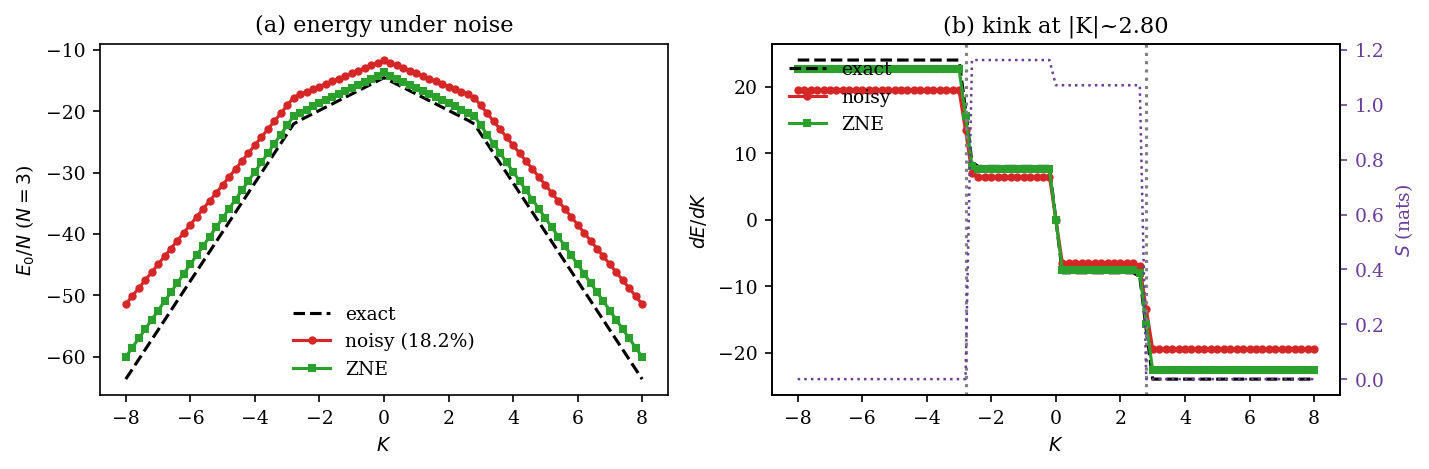

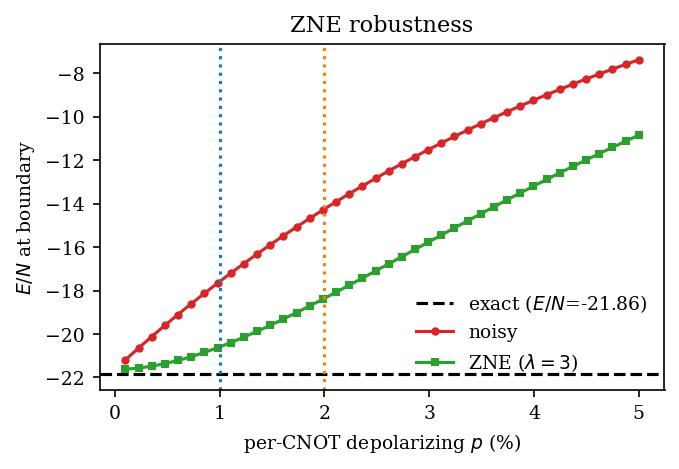

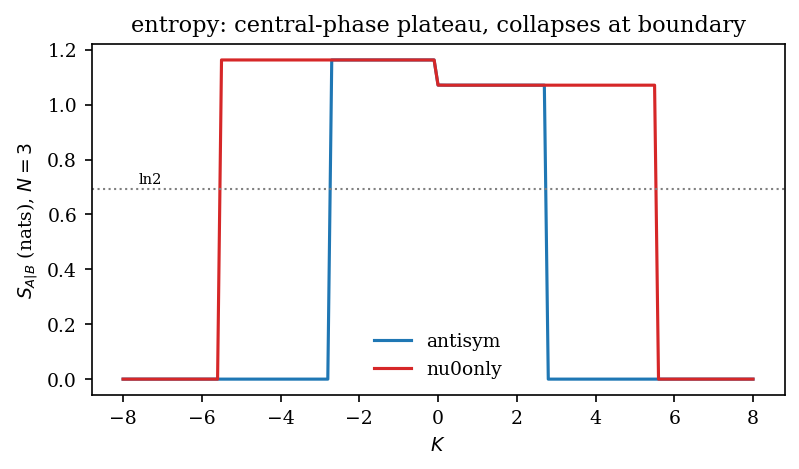

[antisym] boundary |K|~2.80  S_max=1.163  S(at boundary)=0.000  kink suppression=19.0%
  ZNE residual (energy units): p=1% -> 3.79, p=2% -> 10.50, p=5% -> 33.04
  wrote phase_boundary_antisym.png, robustness_antisym.png, entropy_diagnostic.png


In [2]:
"""
Figure generation for the corrected two-flavor Schwinger Hamiltonian.
Self-contained. Toggle CONVENTION below ('antisym' boundary ~2.8, or
'nu0only' boundary ~5.6).  Run:  python esa_figures.py
"""
import numpy as np
from itertools import combinations
from scipy.linalg import eigh
import matplotlib
import matplotlib.colors   # force submodule load (avoids lazy-import glitches)
import matplotlib.pyplot as plt

# ----------------------------------------------------------- settings
CONVENTION = 'antisym'      # 'antisym' or 'nu0only'
X   = 16.0
N   = 3                     # noise figures: N=3, L=2 circuit
NCX = 20                    # CNOTs at N=3, L=2
SPAM = 0.005
plt.rcParams.update({'font.family': 'serif', 'font.size': 9, 'figure.dpi': 150,
                     'lines.linewidth': 1.5, 'savefig.bbox': 'tight'})

# ----------------------------------------------------------- Hamiltonian
def build_basis(Nn):
    nq = 2 * Nn
    b = sorted(sum(1 << q for q in c) for c in combinations(range(nq), Nn))
    return np.array(b, dtype=np.int64), {int(x): i for i, x in enumerate(b)}

def charge(state, n, F=2):                      # corrected: occupation - background
    occ = sum(1.0 for f in range(F) if (state >> (2 * n + f)) & 1)
    return occ - (F / 2.0) * (1 - (-1) ** n)

def nu_of(K, conv):
    a = 2.0 * np.sqrt(X) * K
    return (a, -a) if conv == 'antisym' else (a, 0.0)

def build_H(Nn, K, conv):
    basis, index = build_basis(Nn); d = len(basis); nu = nu_of(K, conv)
    H = np.zeros((d, d))
    for i, s in enumerate(basis):
        for n in range(Nn):
            for f in range(2):
                q = 2 * n + f; z = 1.0 if not (s >> q & 1) else -1.0
                H[i, i] += (nu[f] / 2.0) * (z + 1.0)
        cq = 0.0
        for n in range(Nn - 1):
            cq += charge(s, n); H[i, i] += cq ** 2
        for n in range(Nn - 1):
            for f in range(2):
                p1, p2 = 2 * n + f, 2 * (n + 1) + f
                if (s >> p1 & 1) == 0 and (s >> p2 & 1) == 1:
                    ns = int(s ^ (1 << p1) ^ (1 << p2))
                    if ns in index:
                        j = index[ns]; zs = 1.0
                        for qz in range(p1 + 1, p2):
                            zs *= 1.0 if not (s >> qz & 1) else -1.0
                        H[i, j] += -X * zs; H[j, i] += -X * zs
    return H, basis

def entropy(psi, Nn, basis):
    h = Nn; rho = np.zeros((2 ** h, 2 ** h), complex)
    for i, s in enumerate(basis):
        a = int(s) & ((1 << h) - 1); b = (int(s) >> h) & ((1 << h) - 1)
        for j, s2 in enumerate(basis):
            if ((int(s2) >> h) & ((1 << h) - 1)) == b:
                rho[a, int(s2) & ((1 << h) - 1)] += psi[i] * np.conj(psi[j])
    ev = np.linalg.eigvalsh(rho); ev = ev[ev > 1e-15]
    return float(-np.sum(ev * np.log(ev)))

# ----------------------------------------------------------- exact + noise
def exact_and_mix(Nn, K, conv):
    """Return (E_ground, E_sectormean, ground_entropy)."""
    H, basis = build_H(Nn, K, conv); w, v = eigh(H)
    Emix = float(np.mean(w))                    # Tr(H_phys)/d  (physical maxmix)
    return float(w[0]), Emix, entropy(v[:, 0], Nn, basis)

def noisy(E0, Emix, p, ncx, spam=SPAM):
    w = (1 - p) ** ncx
    wt = w * (1 - 2 * spam)                     # SPAM contraction toward sector mean
    return wt * E0 + (1 - wt) * Emix

def zne(E0, Emix, p, ncx):
    e1 = noisy(E0, Emix, p, ncx); e3 = noisy(E0, Emix, p, 3 * ncx)
    return 1.5 * e1 - 0.5 * e3

def boundary_K(conv, Nn=N):
    Kv = np.linspace(0, 8, 161)
    E = np.array([exact_and_mix(Nn, k, conv)[0] for k in Kv])
    dE = np.gradient(E, Kv)
    return Kv[1 + int(np.argmax(np.abs(np.diff(dE))))]

# ----------------------------------------------------------- FIGURE 1: phase boundary under noise
def fig_phase_boundary(conv, p=0.01):
    Kv = np.linspace(-8, 8, 81)
    ex, mx, S = np.array([exact_and_mix(N, k, conv) for k in Kv]).T
    no = noisy(ex, mx, p, NCX); zn = zne(ex, mx, p, NCX)
    kb = boundary_K(conv)
    fig, ax = plt.subplots(1, 2, figsize=(9.6, 3.2))
    ax[0].plot(Kv, ex / N, 'k--', label='exact')
    ax[0].plot(Kv, no / N, 'o-', color='#d62728', ms=3, label=f'noisy ({100*(1-(1-p)**NCX):.1f}%)')
    ax[0].plot(Kv, zn / N, 's-', color='#2ca02c', ms=3, label='ZNE')
    ax[0].set_xlabel('$K$'); ax[0].set_ylabel(r'$E_0/N$ ($N=3$)')
    ax[0].set_title('(a) energy under noise'); ax[0].legend(frameon=False)
    de = np.gradient(ex, Kv); dn = np.gradient(no, Kv); dz = np.gradient(zn, Kv)
    ax[1].plot(Kv, de, 'k--', label='exact'); ax[1].plot(Kv, dn, 'o-', color='#d62728', ms=3, label='noisy')
    ax[1].plot(Kv, dz, 's-', color='#2ca02c', ms=3, label='ZNE')
    ax[1].axvline(kb, color='gray', ls=':'); ax[1].axvline(-kb, color='gray', ls=':')
    ax[1].set_xlabel('$K$'); ax[1].set_ylabel('$dE/dK$'); ax[1].set_title(f'(b) kink at |K|~{kb:.2f}')
    a2 = ax[1].twinx(); a2.plot(Kv, S, ':', color='#6a3d9a', lw=1.2)
    a2.set_ylabel('$S$ (nats)', color='#6a3d9a'); a2.tick_params(axis='y', colors='#6a3d9a')
    ax[1].legend(frameon=False, loc='upper left')
    fig.tight_layout(); fig.savefig(f'phase_boundary_{conv}.png'); plt.show()
    i_kb = np.argmin(np.abs(Kv - kb))
    sup = 1 - abs(dn[i_kb]) / abs(de[i_kb]) if de[i_kb] != 0 else float('nan')
    return kb, S.max(), float(S[i_kb]), sup

# ----------------------------------------------------------- FIGURE 2: ZNE robustness vs p
def fig_robustness(conv):
    kb = boundary_K(conv)
    Keval = kb - 0.05                            # just inside boundary, avoid degeneracy
    E0, Emix, _ = exact_and_mix(N, Keval, conv)
    ps = np.linspace(0.001, 0.05, 40)
    no = np.array([noisy(E0, Emix, p, NCX) for p in ps])
    zn = np.array([zne(E0, Emix, p, NCX) for p in ps])
    fig, ax = plt.subplots(figsize=(4.6, 3.2))
    ax.axhline(E0 / N, color='k', ls='--', label=f'exact ($E/N$={E0/N:.2f})')
    ax.plot(ps * 100, no / N, 'o-', color='#d62728', ms=3, label='noisy')
    ax.plot(ps * 100, zn / N, 's-', color='#2ca02c', ms=3, label='ZNE ($\\lambda=3$)')
    ax.axvline(1.0, color='#1f77b4', ls=':'); ax.axvline(2.0, color='#ff7f0e', ls=':')
    ax.set_xlabel('per-CNOT depolarizing $p$ (%)'); ax.set_ylabel(r'$E/N$ at boundary')
    ax.set_title('ZNE robustness'); ax.legend(frameon=False)
    fig.tight_layout(); fig.savefig(f'robustness_{conv}.png'); plt.show()
    res = {p: abs(zne(E0, Emix, p, NCX) - E0) for p in (0.01, 0.02, 0.05)}
    return res

# ----------------------------------------------------------- FIGURE 3: entropy diagnostic (both conventions)
def fig_entropy_diagnostic():
    Kv = np.linspace(-8, 8, 161)
    fig, ax = plt.subplots(figsize=(5.4, 3.2))
    for conv, c in (('antisym', '#1f77b4'), ('nu0only', '#d62728')):
        S = np.array([exact_and_mix(N, k, conv)[2] for k in Kv])
        ax.plot(Kv, S, '-', color=c, label=conv)
    ax.axhline(np.log(2), color='gray', ls=':', lw=1); ax.text(-7.6, np.log(2) + 0.02, 'ln2', fontsize=7)
    ax.set_xlabel('$K$'); ax.set_ylabel('$S_{A|B}$ (nats), $N=3$')
    ax.set_title('entropy: central-phase plateau, collapses at boundary')
    ax.legend(frameon=False)
    fig.tight_layout(); fig.savefig('entropy_diagnostic.png'); plt.show()

if __name__ == '__main__':
    kb, smax, sb, sup = fig_phase_boundary(CONVENTION)
    res = fig_robustness(CONVENTION)
    fig_entropy_diagnostic()
    print(f"[{CONVENTION}] boundary |K|~{kb:.2f}  S_max={smax:.3f}  S(at boundary)={sb:.3f}  kink suppression={100*sup:.1f}%")
    print(f"  ZNE residual (energy units): p=1% -> {res[0.01]:.2f}, p=2% -> {res[0.02]:.2f}, p=5% -> {res[0.05]:.2f}")
    print(f"  wrote phase_boundary_{CONVENTION}.png, robustness_{CONVENTION}.png, entropy_diagnostic.png")

In [1]:
import os, shutil

FIGS = "figs"
os.makedirs(FIGS, exist_ok=True)

# figures the manuscript references, plus the regenerated noise/diagnostic ones
paper_figs = [
    "jack_fig1_baseline.png",      # Fig 1  foundation
    "jack_fig2_master.png",        # Fig 2  expressibility
    "esa_fig1_ksweep.png",         # Fig 3  GI vs HW sweep
    "esa_fig4_penalty.png",        # Fig 4  penalty
    "esa_fig2_stability.png",      # Fig 5  stability
    "esa_fig3_convergence.png",    # Fig 6  convergence
    "phase_boundary_final.png",    # Fig 7  (old name)
    "robustness_limit_final.png",  # Fig 8  (old name)
    # regenerated from esa_figures.py (whichever convention you ran):
    "phase_boundary_antisym.png",
    "robustness_antisym.png",
    "phase_boundary_nu0only.png",
    "robustness_nu0only.png",
    "entropy_diagnostic.png",
]

moved, missing = [], []
for f in paper_figs:
    if os.path.exists(f):
        dest = os.path.join(FIGS, f)
        if os.path.exists(dest):
            os.remove(dest)          # overwrite if already there
        shutil.move(f, dest)
        moved.append(f)
    else:
        missing.append(f)

print(f"moved {len(moved)} file(s) into ./{FIGS}/")
for f in moved:
    print("  ", f)
if missing:
    print("\nnot found here (skipped):")
    for f in missing:
        print("  ", f)

moved 6 file(s) into ./figs/
   jack_fig1_baseline.png
   jack_fig2_master.png
   esa_fig1_ksweep.png
   esa_fig4_penalty.png
   esa_fig2_stability.png
   esa_fig3_convergence.png

not found here (skipped):
   phase_boundary_final.png
   robustness_limit_final.png
   phase_boundary_antisym.png
   robustness_antisym.png
   phase_boundary_nu0only.png
   robustness_nu0only.png
   entropy_diagnostic.png


In [2]:
import os, shutil, glob

OTHER = "otherfigs"
os.makedirs(OTHER, exist_ok=True)

exts = ("*.png", "*.jpg", "*.jpeg", "*.gif", "*.bmp", "*.tif", "*.tiff", "*.webp")

moved = []
for pat in exts:
    for f in glob.glob(pat):              # current folder only, won't touch figs/
        if os.path.isfile(f):
            dest = os.path.join(OTHER, f)
            if os.path.exists(dest):
                os.remove(dest)
            shutil.move(f, dest)
            moved.append(f)

print(f"moved {len(moved)} leftover image(s) into ./{OTHER}/")
for f in moved:
    print("  ", f)

moved 20 leftover image(s) into ./otherfigs/
   esa_fig3_penalty.png
   esa_fig4_convergence.png
   fig1_phase_diagram.png
   fig1_sectors.png
   fig2_ansatz.png
   fig2_ansatz_gates.png
   fig2_convergence.png
   fig3_accuracy.png
   fig3_comparison.png
   fig4_convergence.png
   fig4_particle_number.png
   fig5_entanglement.png
   fig6_scaling.png
   jack_fig2_error_vs_L.png
   jack_fig3_convergence.png
   jack_fig4_gradient_variance.png
   jack_fig4_stability.png
   jack_fig5_barren_phasediag.png
   jack_fig5_finite_size.png
   jack_fig6_finitesize.png


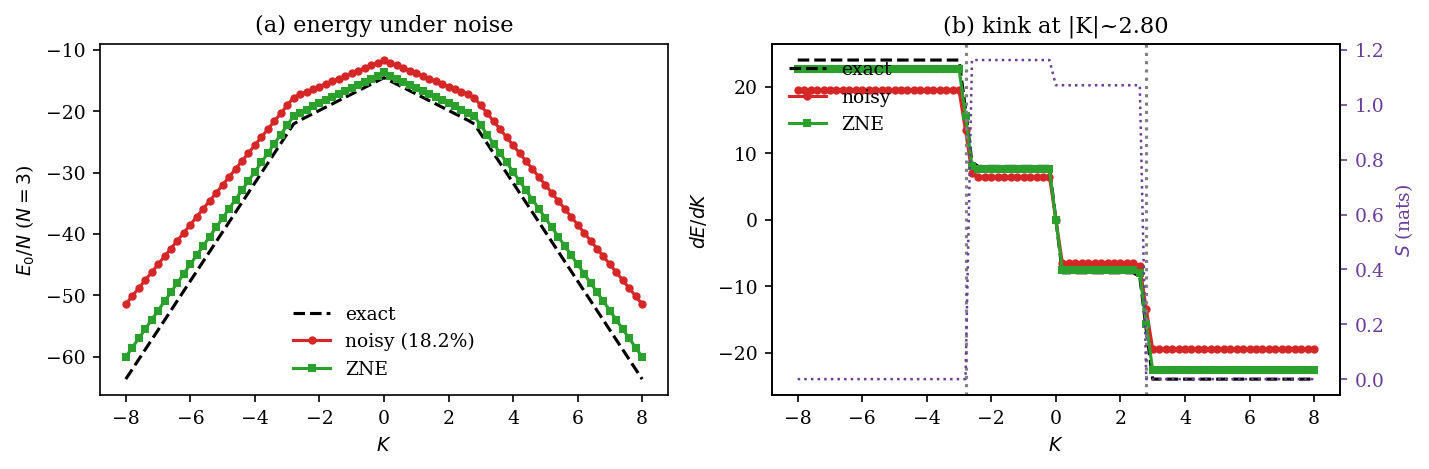

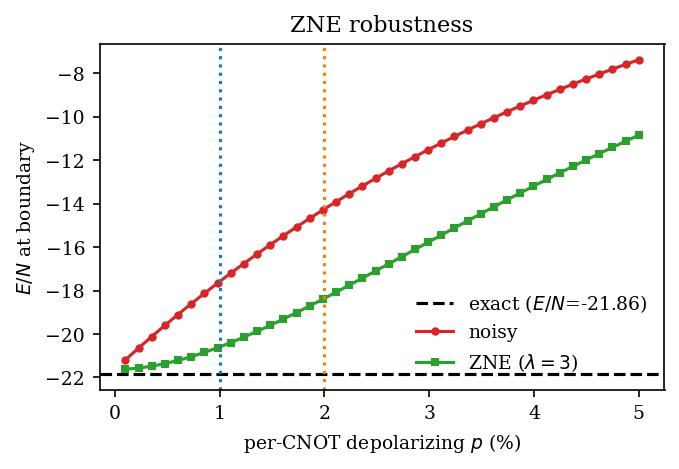

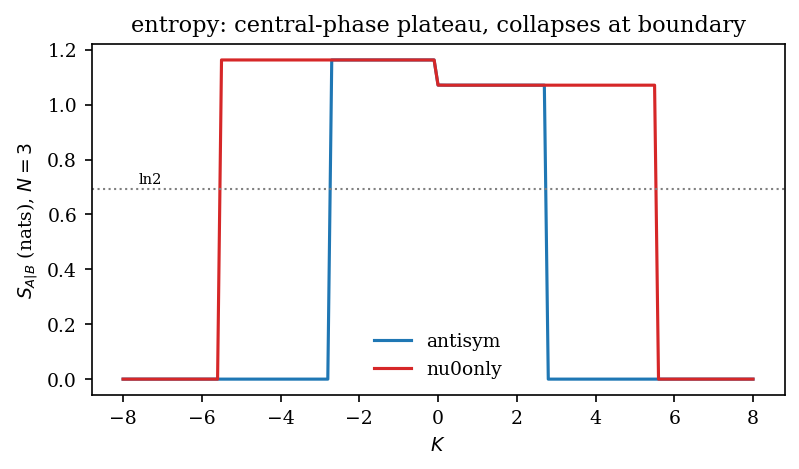

[antisym] boundary |K|~2.80  S_max=1.163  S(at boundary)=0.000  kink suppression=19.0%
  ZNE residual (energy units): p=1% -> 3.79, p=2% -> 10.50, p=5% -> 33.04
  wrote figs/phase_boundary_final.png, figs/robustness_limit_final.png, figs/entropy_diagnostic.png


In [4]:
"""
Figure generation for the corrected two-flavor Schwinger Hamiltonian.
Self-contained. Toggle CONVENTION below ('antisym' boundary ~2.8, or
'nu0only' boundary ~5.6).  Run:  python esa_figures.py

Noise model (matches the manuscript): a charge-conserving circuit depolarizes
toward the maximally mixed state WITHIN the physical sector, so
    E_noisy(K) = w*E_exact(K) + (1-w)*Tr(H_phys(K))/d,   w = (1-p)^nCX,
and first-order ZNE folds nCX->3 nCX with Richardson E_mit = 1.5 E(1) - 0.5 E(3).
"""
import os
import numpy as np
from itertools import combinations
from scipy.linalg import eigh
import matplotlib
import matplotlib.colors   # force submodule load (avoids lazy-import glitches)
import matplotlib.pyplot as plt

# ----------------------------------------------------------- settings
CONVENTION = 'antisym'      # 'antisym' or 'nu0only'
X   = 16.0
N   = 3                     # noise figures: N=3, L=2 circuit
NCX = 20                    # CNOTs at N=3, L=2
SPAM = 0.005
OUTDIR = 'figs'                # figures saved straight into ./figs/
os.makedirs(OUTDIR, exist_ok=True)
plt.rcParams.update({'font.family': 'serif', 'font.size': 9, 'figure.dpi': 150,
                     'lines.linewidth': 1.5, 'savefig.bbox': 'tight'})

# ----------------------------------------------------------- Hamiltonian
def build_basis(Nn):
    nq = 2 * Nn
    b = sorted(sum(1 << q for q in c) for c in combinations(range(nq), Nn))
    return np.array(b, dtype=np.int64), {int(x): i for i, x in enumerate(b)}

def charge(state, n, F=2):                      # corrected: occupation - background
    occ = sum(1.0 for f in range(F) if (state >> (2 * n + f)) & 1)
    return occ - (F / 2.0) * (1 - (-1) ** n)

def nu_of(K, conv):
    a = 2.0 * np.sqrt(X) * K
    return (a, -a) if conv == 'antisym' else (a, 0.0)

def build_H(Nn, K, conv):
    basis, index = build_basis(Nn); d = len(basis); nu = nu_of(K, conv)
    H = np.zeros((d, d))
    for i, s in enumerate(basis):
        for n in range(Nn):
            for f in range(2):
                q = 2 * n + f; z = 1.0 if not (s >> q & 1) else -1.0
                H[i, i] += (nu[f] / 2.0) * (z + 1.0)
        cq = 0.0
        for n in range(Nn - 1):
            cq += charge(s, n); H[i, i] += cq ** 2
        for n in range(Nn - 1):
            for f in range(2):
                p1, p2 = 2 * n + f, 2 * (n + 1) + f
                if (s >> p1 & 1) == 0 and (s >> p2 & 1) == 1:
                    ns = int(s ^ (1 << p1) ^ (1 << p2))
                    if ns in index:
                        j = index[ns]; zs = 1.0
                        for qz in range(p1 + 1, p2):
                            zs *= 1.0 if not (s >> qz & 1) else -1.0
                        H[i, j] += -X * zs; H[j, i] += -X * zs
    return H, basis

def entropy(psi, Nn, basis):
    h = Nn; rho = np.zeros((2 ** h, 2 ** h), complex)
    for i, s in enumerate(basis):
        a = int(s) & ((1 << h) - 1); b = (int(s) >> h) & ((1 << h) - 1)
        for j, s2 in enumerate(basis):
            if ((int(s2) >> h) & ((1 << h) - 1)) == b:
                rho[a, int(s2) & ((1 << h) - 1)] += psi[i] * np.conj(psi[j])
    ev = np.linalg.eigvalsh(rho); ev = ev[ev > 1e-15]
    return float(-np.sum(ev * np.log(ev)))

# ----------------------------------------------------------- exact + noise
def exact_and_mix(Nn, K, conv):
    """Return (E_ground, E_sectormean, ground_entropy)."""
    H, basis = build_H(Nn, K, conv); w, v = eigh(H)
    Emix = float(np.mean(w))                    # Tr(H_phys)/d  (physical maxmix)
    return float(w[0]), Emix, entropy(v[:, 0], Nn, basis)

def noisy(E0, Emix, p, ncx, spam=SPAM):
    w = (1 - p) ** ncx
    # SPAM adds a small extra contraction toward the sector mean
    wt = w * (1 - 2 * spam)
    return wt * E0 + (1 - wt) * Emix

def zne(E0, Emix, p, ncx):
    e1 = noisy(E0, Emix, p, ncx); e3 = noisy(E0, Emix, p, 3 * ncx)
    return 1.5 * e1 - 0.5 * e3

def boundary_K(conv, Nn=N):
    Kv = np.linspace(0, 8, 161)
    E = np.array([exact_and_mix(Nn, k, conv)[0] for k in Kv])
    dE = np.gradient(E, Kv)
    return Kv[1 + int(np.argmax(np.abs(np.diff(dE))))]

# ----------------------------------------------------------- FIGURE 1: phase boundary under noise
def fig_phase_boundary(conv, p=0.01):
    Kv = np.linspace(-8, 8, 81)
    ex, mx, S = np.array([exact_and_mix(N, k, conv) for k in Kv]).T
    no = noisy(ex, mx, p, NCX); zn = zne(ex, mx, p, NCX)
    kb = boundary_K(conv)
    fig, ax = plt.subplots(1, 2, figsize=(9.6, 3.2))
    ax[0].plot(Kv, ex / N, 'k--', label='exact')
    ax[0].plot(Kv, no / N, 'o-', color='#d62728', ms=3, label=f'noisy ({100*(1-(1-p)**NCX):.1f}%)')
    ax[0].plot(Kv, zn / N, 's-', color='#2ca02c', ms=3, label='ZNE')
    ax[0].set_xlabel('$K$'); ax[0].set_ylabel(r'$E_0/N$ ($N=3$)')
    ax[0].set_title('(a) energy under noise'); ax[0].legend(frameon=False)
    de = np.gradient(ex, Kv); dn = np.gradient(no, Kv); dz = np.gradient(zn, Kv)
    ax[1].plot(Kv, de, 'k--', label='exact'); ax[1].plot(Kv, dn, 'o-', color='#d62728', ms=3, label='noisy')
    ax[1].plot(Kv, dz, 's-', color='#2ca02c', ms=3, label='ZNE')
    ax[1].axvline(kb, color='gray', ls=':'); ax[1].axvline(-kb, color='gray', ls=':')
    ax[1].set_xlabel('$K$'); ax[1].set_ylabel('$dE/dK$'); ax[1].set_title(f'(b) kink at |K|~{kb:.2f}')
    a2 = ax[1].twinx(); a2.plot(Kv, S, ':', color='#6a3d9a', lw=1.2)
    a2.set_ylabel('$S$ (nats)', color='#6a3d9a'); a2.tick_params(axis='y', colors='#6a3d9a')
    ax[1].legend(frameon=False, loc='upper left')
    fig.tight_layout(); fig.savefig(os.path.join(OUTDIR,'phase_boundary_final.png')); plt.show()
    # kink suppression
    i_kb = np.argmin(np.abs(Kv - kb))
    sup = 1 - abs(dn[i_kb]) / abs(de[i_kb]) if de[i_kb] != 0 else float('nan')
    return kb, S.max(), float(S[i_kb]), sup

# ----------------------------------------------------------- FIGURE 2: ZNE robustness vs p
def fig_robustness(conv):
    kb = boundary_K(conv)
    # evaluate just inside the boundary to avoid the exact degeneracy point
    Keval = kb - 0.05
    E0, Emix, _ = exact_and_mix(N, Keval, conv)
    ps = np.linspace(0.001, 0.05, 40)
    no = np.array([noisy(E0, Emix, p, NCX) for p in ps])
    zn = np.array([zne(E0, Emix, p, NCX) for p in ps])
    fig, ax = plt.subplots(figsize=(4.6, 3.2))
    ax.axhline(E0 / N, color='k', ls='--', label=f'exact ($E/N$={E0/N:.2f})')
    ax.plot(ps * 100, no / N, 'o-', color='#d62728', ms=3, label='noisy')
    ax.plot(ps * 100, zn / N, 's-', color='#2ca02c', ms=3, label='ZNE ($\\lambda=3$)')
    ax.axvline(1.0, color='#1f77b4', ls=':'); ax.axvline(2.0, color='#ff7f0e', ls=':')
    ax.set_xlabel('per-CNOT depolarizing $p$ (%)'); ax.set_ylabel(r'$E/N$ at boundary')
    ax.set_title('ZNE robustness'); ax.legend(frameon=False)
    fig.tight_layout(); fig.savefig(os.path.join(OUTDIR,'robustness_limit_final.png')); plt.show()
    res = {p: abs(zne(E0, Emix, p, NCX) - E0) for p in (0.01, 0.02, 0.05)}
    return res

# ----------------------------------------------------------- FIGURE 3: entropy diagnostic (both conventions)
def fig_entropy_diagnostic():
    Kv = np.linspace(-8, 8, 161)
    fig, ax = plt.subplots(figsize=(5.4, 3.2))
    for conv, c in (('antisym', '#1f77b4'), ('nu0only', '#d62728')):
        S = np.array([exact_and_mix(N, k, conv)[2] for k in Kv])
        ax.plot(Kv, S, '-', color=c, label=conv)
    ax.axhline(np.log(2), color='gray', ls=':', lw=1); ax.text(-7.6, np.log(2) + 0.02, 'ln2', fontsize=7)
    ax.set_xlabel('$K$'); ax.set_ylabel('$S_{A|B}$ (nats), $N=3$')
    ax.set_title('entropy: central-phase plateau, collapses at boundary')
    ax.legend(frameon=False)
    fig.tight_layout(); fig.savefig(os.path.join(OUTDIR,'entropy_diagnostic.png')); plt.show()

if __name__ == '__main__':
    kb, smax, sb, sup = fig_phase_boundary(CONVENTION)
    res = fig_robustness(CONVENTION)
    fig_entropy_diagnostic()
    print(f"[{CONVENTION}] boundary |K|~{kb:.2f}  S_max={smax:.3f}  S(at boundary)={sb:.3f}  kink suppression={100*sup:.1f}%")
    print(f"  ZNE residual (energy units): p=1% -> {res[0.01]:.2f}, p=2% -> {res[0.02]:.2f}, p=5% -> {res[0.05]:.2f}")
    print(f"  wrote {OUTDIR}/phase_boundary_final.png, {OUTDIR}/robustness_limit_final.png, {OUTDIR}/entropy_diagnostic.png")